In [29]:
import numpy as np
import tensorflow as tf 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense,Input
import warnings 
warnings.filterwarnings('ignore')

In [30]:
with open(r"../datasets/next_word_prediction.txt", "r", encoding="cp1252", errors="replace") as f:
    data = f.read()

In [31]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([data])

In [32]:
len(tokenizer.word_index)

8931

In [33]:
input_seq=[]
for sentence in data.split('\n'):
    tokenized_sentence= tokenizer.texts_to_sequences([sentence])[0]
    for i in range(1,len(tokenized_sentence)):
        input_seq.append(tokenized_sentence[:i+1])

In [34]:
max_len = max([len(x) for x in input_seq])
print(max_len)

20


## Padding

In [35]:
padded_input_seq = pad_sequences(input_seq , max_len , padding = 'pre')

X = padded_input_seq[:,:-1]
y = padded_input_seq[:,-1]

y = to_categorical(y,num_classes = 8932)
y.shape

(101619, 8932)

## LSTM Model

In [36]:
model = Sequential([
    Input(shape=(X.shape[1],)),
    Embedding(input_dim=8932, output_dim=400),
    LSTM(100),
    Dense(8932, activation='softmax')
])

In [37]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 19, 400)           3572800   
                                                                 
 lstm_2 (LSTM)               (None, 100)               200400    
                                                                 
 dense_2 (Dense)             (None, 8932)              902132    
                                                                 
Total params: 4,675,332
Trainable params: 4,675,332
Non-trainable params: 0
_________________________________________________________________


In [38]:
model.compile(loss = "categorical_crossentropy" , optimizer ='adam' , metrics = ['accuracy'])

In [39]:
Model: "sequential"

In [40]:
print(X.shape)

(101619, 19)


In [41]:
history = model.fit(
    X,
    y,
    epochs=25,
    validation_split=0.2
)

Epoch 1/25
2541/2541 [==============================] - 92s 27ms/step - loss: 6.2625 - accuracy: 0.0778 - val_loss: 6.1392 - val_accuracy: 0.1029
Epoch 2/25
2541/2541 [==============================] - 40s 16ms/step - loss: 5.4632 - accuracy: 0.1312 - val_loss: 6.0663 - val_accuracy: 0.1238
Epoch 3/25
2541/2541 [==============================] - 26s 10ms/step - loss: 5.0323 - accuracy: 0.1591 - val_loss: 6.0831 - val_accuracy: 0.1340
Epoch 4/25
2541/2541 [==============================] - 27s 10ms/step - loss: 4.6759 - accuracy: 0.1843 - val_loss: 6.2075 - val_accuracy: 0.1333
Epoch 5/25
2541/2541 [==============================] - 25s 10ms/step - loss: 4.3522 - accuracy: 0.2086 - val_loss: 6.3132 - val_accuracy: 0.1344
Epoch 6/25
2541/2541 [==============================] - 28s 11ms/step - loss: 4.0488 - accuracy: 0.2343 - val_loss: 6.4727 - val_accuracy: 0.1320
Epoch 7/25
2541/2541 [==============================] - 28s 11ms/step - loss: 3.7627 - accuracy: 0.2641 - val_loss: 6.6353 -

In [44]:
sample_text = "sherlock"
for i in range(4):
    tokenized_text = tokenizer.texts_to_sequences([sample_text])[0]
    
    padded_text = pad_sequences([tokenized_text],maxlen = 19, padding= 'pre')
    
    nxt_word = np.argmax(model.predict(padded_text))
    
    for word, index in tokenizer.word_index.items():
        if index == nxt_word:
            sample_text = sample_text+" "+word
print(sample_text)

1/1 [==============================] - 0s 20ms/step
sherlock holmes was a man


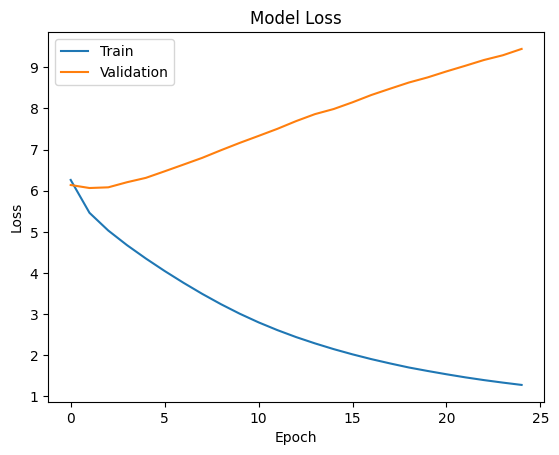

In [45]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

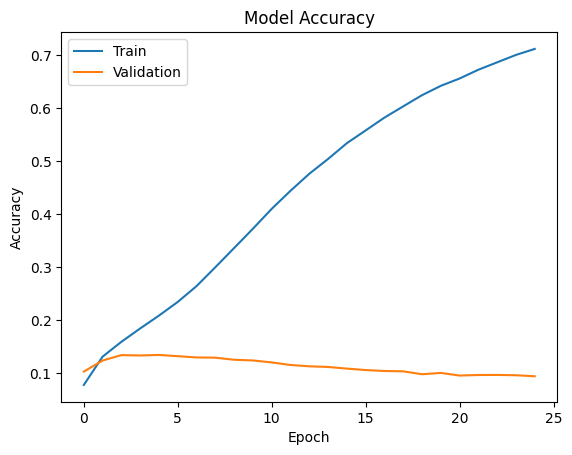

In [46]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()